# Lunar Lander

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/Machine_Learning_Specialization/portfolio-2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Train an intelligent agent to land a lunar module safely on a landing pad.

We will use the [Gymnasium](https://gymnasium.farama.org) library, which is an open source Python library for developing and comparing reinforcement learning algorithms by providing a standard API to communicate between learning algorithms and environments, as well as a standard set of environments compliant with that API. To put it simply, an environment represents a problem or task to be solved. We will try to solve the [Lunar Lander](https://gymnasium.farama.org/environments/box2d/lunar_lander/) environment using reinforcement learning.

[Reinforcement learning](https://en.wikipedia.org/wiki/Reinforcement_learning) is a type of machine learning technique where an [intelligent agent](https://en.wikipedia.org/wiki/Intelligent_agent) learns to perform a task through repeated trial and error interactions with a dynamic environment. This learning approach enables the agent to make a series of decisions that maximize a reward metric for the task without human intervention and without being explicitly programmed to achieve the task.

## Import libraries

In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from IPython.display import HTML
import tensorflow as tf
from keras import Sequential, Input, layers, optimizers, losses
import time
import numpy as np
from collections import deque, namedtuple
import random

sns.set_style(style="whitegrid")

2025-06-30 13:09:12.820945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751310552.834085    5815 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751310552.838706    5815 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Visualize the environment

In [3]:
# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array_list")

# Reset the environment to generate the first observation
observation, info = env.reset()
episode_over = False

while not episode_over:
    # This is where we would insert our policy
    action = env.action_space.sample()

    # Step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can stop the episode
    episode_over = terminated or truncated

# Render the environment to help visualise what the agent sees
frames_list = env.render()
env.close()

/home/luis-mendoza/miniforge3/envs/gymnasium/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
frames = []

fig, ax = plt.subplots()

for image in frames_list:
    plt.tight_layout()
    ax.set_title("Frames")
    ax.axis("off")
    frame = ax.imshow(image, animated=True)
    frames.append([frame])
    
anim = animation.ArtistAnimation(fig, frames, interval=50, blit=True, repeat_delay=1000)
plt.close(fig)

HTML(anim.to_html5_video())

## Understand the environment

### Description

This environment is a classic rocket trajectory optimization problem. According to Pontryagin’s maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off.

There are two environment versions: discrete or continuous. The landing pad is always at coordinates (0, 0). The coordinates are the first two numbers in the state vector. Landing outside of the landing pad is possible. Fuel is infinite, so an agent can learn to fly and then land on its first attempt.

### Action Space

There are four discrete actions available:

- 0: do nothing
- 1: fire left orientation engine
- 2: fire main engine
- 3: fire right orientation engine

### Observation Space

The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

### Rewards

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.
- is increased/decreased the slower/faster the lander is moving.
- is decreased the more the lander is tilted (angle not horizontal).
- is increased by 10 points for each leg that is in contact with the ground.
- is decreased by 0.03 points each frame a side engine is firing.
- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.

### Starting State

The lander starts at the top center of the viewport with a random initial force applied to its center of mass.

### Episode Termination

The episode finishes if:

- the lander crashes (the lander body gets in contact with the moon);
- the lander gets outside of the viewport (x coordinate is greater than 1);
- the lander is not awake (it doesn’t move and doesn’t collide with any other body).

### Environment’s dynamics

The [step()](https://gymnasium.farama.org/api/env/#gymnasium.Env.step) method runs a single time step of the environment's dynamics. It accepts an action and returns five values:

- observation – An element of the environment’s observation_space as the next observation due to the agent actions.

- reward – The reward as a result of taking the action.

- terminated – Whether the agent reaches the terminal state (as defined under the MDP of the task) which can be positive or negative.

- truncated – Whether the truncation condition outside the scope of the MDP is satisfied. Typically, this is a timelimit, but could also be used to indicate an agent physically going out of bounds. Can be used to end the episode prematurely before a terminal state is reached.

- info – Contains auxiliary diagnostic information (helpful for debugging, learning, and logging). This might, for instance, contain: metrics that describe the agent’s performance state, variables that are hidden from observations, or individual reward terms that are combined to produce the total reward.

For a full description of the environment, check out the [Gymnasium documentation](https://gymnasium.farama.org/environments/box2d/lunar_lander/).

## Build a Deep Q-Network with experience replay

A [Deep Q-Network (DQN)](https://arxiv.org/pdf/1312.5602v1) is a reinforcement learning algorithm that combines [Q-learning](https://en.wikipedia.org/wiki/Q-learning) with deep neural networks to approximate the Q-value function for each (state, action) pair. This approach allows DQN to handle high-dimensional state spaces and learn optimal policies in complex environments, such as playing video games or controlling robots. DQN uses a replay memory buffer to store past experiences and a deep neural network to estimate Q-values, which helps in stabilizing the training process and preventing overfitting.

In [5]:
observation_shape = env.observation_space.shape
number_actions = env.action_space.n

# Q-Network
q_network = Sequential([Input(shape=observation_shape),
                        layers.Dense(units=64, activation='relu'),
                        layers.Dense(units=64, activation='relu'),
                        layers.Dense(units=number_actions, activation='linear')])

# Target Q*-Network
target_q_network = Sequential([Input(shape=observation_shape),
                               layers.Dense(units=64, activation='relu'),
                               layers.Dense(units=64, activation='relu'),
                               layers.Dense(units=number_actions, activation='linear')])

q_network.summary()

I0000 00:00:1751310563.711931    5815 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1755 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,996 (19.52 KB)

 Trainable params: 4,996 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

The agent experiences are sequential by nature, so if the agent tries to learn from these consecutive experiences it can run into problems due to the strong correlations between them. To avoid this, we employ a technique known as [Experience Replay](https://arxiv.org/pdf/2007.06700) to generate uncorrelated experiences for training our agent. Experience replay consists of storing the agent's experiences (i.e the states, actions, and rewards the agent receives) in a memory buffer and then sampling a random mini-batch of experiences from the buffer to do the learning. The experience tuples $(S_t, A_t, R_t, S_{t+1})$ will be added to the memory buffer at each time step as the agent interacts with the environment.

By using experience replay we avoid problematic correlations, oscillations and instabilities. In addition, experience replay also allows the agent to potentially use the same experience in multiple weight updates, which increases data efficiency.

In [6]:
def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
        experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples.
        gamma: (float) The discount factor.
        q_network: (tf.keras.Sequential) Keras model for predicting the q_values.
        target_q_network: (tf.keras.Sequential) Keras model for predicting the targets.

    Returns:
        loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between the y targets and the Q(s,a) values.
    """
    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_values = experiences
    
    # Compute max Q*(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q*(s,a)
    y_targets = rewards + (gamma * max_qsa * (1 - done_values))
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]), tf.cast(actions, tf.int32)], axis=1))
    
    # Compute the loss
    loss = losses.mean_squared_error(y_targets, q_values)
    
    return loss

In [7]:
optimizer = optimizers.Adam()

@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
        experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
        gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # Update the weights of target Q*-Network (https://arxiv.org/pdf/2008.10861)
    tau = 1e-3 # Soft update parameter
    
    for target_weights, q_net_weights in zip(target_q_network.weights, q_network.weights):
        target_weights.assign(tau * q_net_weights + (1 - tau) * target_weights)

## Train the Deep Q-Network

Algorithm implementation:

1. We initialize the **memory_buffer** with a capacity of $maxlen = memorysize$. We are using a deque as the data structure for our **memory_buffer**.
2. We initialize the **target_q_network** by setting its weights to be equal to those of the **q_network**.
3. We start the outer loop. We have set $number\_episodes = 2000$. This number is reasonable because the agent should be able to solve the Lunar Lander environment in less than 2000 episodes.
4. We use the **reset()** method to reset the environment to the initial state and get the initial state.
5. We start the inner loop. We have set $max\_number\_timesteps = 1000$. This means that the episode will automatically terminate if the episode hasn't terminated after 1000 time steps.
6. The agent observes the current state and chooses an action using an $\epsilon$-greedy policy. Our agent starts out using a value of $epsilon = 1$ which yields an $\epsilon$-greedy policy that is equivalent to the equiprobable random policy. This means that at the beginning of our training, the agent is just going to take random actions regardless of the observed state. As training progresses we will decrease the value of slowly towards a minimum value using a given $\epsilon$-decay rate. We want this minimum value to be close to zero because a value of $epsilon = 0$ will yield an $\epsilon$-greedy policy that is equivalent to the greedy policy. This means that towards the end of training, the agent will learn towards selecting the action that it believes (based on its past experiences) will maximize $Q(s, a)$. We will set the minimum $\epsilon$ value to be 0.01 and not exactly 0 because we always want to keep a little bit of exploration during training.
7. We use the **step()** method to take the given action in the environment and get the reward and the **next_state**.
8. We store the **experience(state, action, reward, next_state, done)** tuple in our **memory_buffer**. We also store the done variable so that we can keep track of when an episode terminates.
9. We check if the conditions are met to perform a learning update. We check if $number\_steps\_for\_update = 4$ time steps have occured and if our **memory_buffer** has enough experience tuples to fill a mini-batch. For example, if the mini-batch size is 64, then our **memory_buffer** should have at least 64 experience tuples in order to pass the latter condition.
10. If the update variable is True then we perform a learning update. The learning update consists of sampling a random mini-batch of experience tuples from our **memory_buffer**, setting the $y$ targets, performing gradient descent, and updating the weights of the networks.
11. At the end of each iteration of the inner loop we set **next_state** as our new state so that the loop can start again from this new state. In addition, we check if the episode has reached a terminal state (i.e we check if $done = True$). If a terminal state has been reached, then we break out of the inner loop.
12. At the end of each iteration of the outer loop we update the value of $\epsilon$, and check if the environment has been solved. We consider that the environment has been solved if the agent receives an average of 200 points in the last 100 episodes. If the environment has not been solved we continue the outer loop and start a new episode.

In [8]:
memory_size = 100000            # Size of memory buffer
gamma = 0.995                   # Discount factor
number_steps_for_update = 4     # Perform a learning update every C time steps
minibatch_size = 64             # Mini-batch size
epsilon = 1.0                   # Initial ε value for ε-greedy policy
e_decay = 0.995                 # ε decay rate for ε-greedy policy
e_min = 0.01                    # Minimum ε value for ε-greedy policy
number_points_for_average = 100 # Number of total points to use for averaging
number_episodes = 2000
max_number_timesteps = 1000
total_points_history = []

# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

# Create a memory buffer D with capacity N
memory_buffer = deque(maxlen=memory_size)

# Set the target Q*-Network weights equal to the Q-Network weights
target_q_network.set_weights(q_network.get_weights())

for i in range(number_episodes):
    episode_start_time = time.time()

    # Reset the environment to the initial state and get the initial state
    state, info = env.reset()
    total_points = 0
    
    for t in range(max_number_timesteps):
        # From the current state S choose an action A using an ε-greedy policy
        state_qn = np.expand_dims(state, axis=0) # State needs to be the right shape for the q_network
        q_values = q_network(state_qn)
        action = np.argmax(q_values.numpy()[0]) if random.random() > epsilon else random.choice(np.arange(4))
        
        # Take action A and receive reward R and the next state S'
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Store experience tuple (S, A, R, S') in the memory buffer.
        # We store the done variable as well for convenience.
        memory_buffer.append(experience(state, action, reward, next_state, done))
        
        # Only update the network every number_steps_for_update time steps
        update = True if (t + 1) % number_steps_for_update == 0 and len(memory_buffer) > minibatch_size else False
        
        if update:
            # Sample random mini-batch of experience tuples (S, A, R, S') from D
            experiences = random.sample(memory_buffer, k=minibatch_size)
            states = tf.convert_to_tensor(np.array([e.state for e in experiences if e is not None]), dtype=tf.float32)
            actions = tf.convert_to_tensor(np.array([e.action for e in experiences if e is not None]), dtype=tf.float32)
            rewards = tf.convert_to_tensor(np.array([e.reward for e in experiences if e is not None]), dtype=tf.float32)
            next_states = tf.convert_to_tensor(np.array([e.next_state for e in experiences if e is not None]), dtype=tf.float32)
            done_values = tf.convert_to_tensor(np.array([e.done for e in experiences if e is not None]).astype(np.uint8), dtype=tf.float32)
            experiences = (states, actions, rewards, next_states, done_values)
            
            # Set the y targets, perform a gradient descent step, and update the network weights
            agent_learn(experiences, gamma)
        
        state = next_state.copy()
        total_points += reward
        
        if done: break
    
    total_points_history.append(total_points)
    average_latest_points = np.mean(total_points_history[-number_points_for_average:])
    
    # Update the ε value
    epsilon = max(e_min, e_decay * epsilon)

    episode_stop_time = time.time()

    print(f"\rEpisode {i + 1}/{number_episodes} | elapsed time: {(episode_stop_time - episode_start_time):.3f}s, total points average of the last {number_points_for_average} episodes: {average_latest_points:.2f}", end="")

    if (i + 1) % number_points_for_average == 0:
        print(f"\rEpisode {i + 1}/{number_episodes} | elapsed time: {(episode_stop_time - episode_start_time):.3f}s, total points average of the last {number_points_for_average} episodes: {average_latest_points:.2f}")

    # We will consider that the environment is solved if we get an average of 200 points in the last 100 episodes
    if average_latest_points >= 200:
        print(f"\n\nEnvironment solved in {i + 1} episodes!")
        break

Episode 100/2000 | elapsed time: 0.906s, total points average of the last 100 episodes: -175.31
Episode 200/2000 | elapsed time: 4.890s, total points average of the last 100 episodes: -89.755
Episode 300/2000 | elapsed time: 5.312s, total points average of the last 100 episodes: -54.33
Episode 400/2000 | elapsed time: 2.287s, total points average of the last 100 episodes: 73.207
Episode 500/2000 | elapsed time: 4.767s, total points average of the last 100 episodes: 143.42
Episode 596/2000 | elapsed time: 3.970s, total points average of the last 100 episodes: 201.60

Environment solved in 596 episodes!


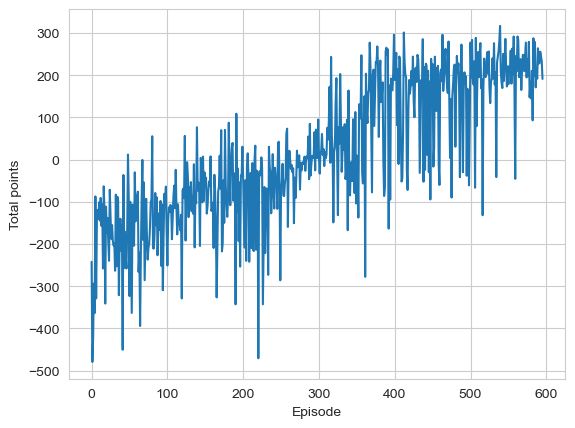

In [9]:
plt.figure()
plt.plot(total_points_history)
plt.xlabel("Episode")
plt.ylabel("Total points")
plt.show()

## Evaluate the Deep Q-Network

Let's see our agent interacting with the environment using the trained Q-Network. We should note that since the lunar lander starts with a random initial force applied to its center of mass, every time we run the cell below we will see a different video. If the agent was trained properly, it should be able to land the lunar lander in the landing pad every time, regardless of the initial force applied to its center of mass.

In [14]:
# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array_list")

# Reset the environment to generate the first observation
observation, info = env.reset()
episode_over = False

while not episode_over:
    # This is where we would insert our policy
    observation = np.expand_dims(observation, axis=0)
    q_values = q_network(observation)
    action = np.argmax(q_values.numpy()[0])

    # Step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can stop the episode
    episode_over = terminated or truncated

# Render the environment to help visualise what the agent sees
frames_list = env.render()
env.close()

In [15]:
frames = []

fig, ax = plt.subplots()

for image in frames_list:
    plt.tight_layout()
    ax.set_title("Frames")
    ax.axis("off")
    frame = ax.imshow(image, animated=True)
    frames.append([frame])
    
anim = animation.ArtistAnimation(fig, frames, interval=50, blit=True, repeat_delay=1000)
plt.close(fig)

HTML(anim.to_html5_video())